# Dataset collection


### Dataset description

Dataset consists of visible, radar, and NDVI imagery. Dataset is from the satellites Sentinel 1 and 2. Data was retrieved from [Mendeley](https://data.mendeley.com/datasets/xjcr5k4c9t/3), which isn't the source of the Sentinel 1 and 2 data, but as a pilot study to reduce project
complexity this model will be built only using dataset.

In the future it might be worth looking at the pacific islands and evaluating my model specifically there, since that will be the main focus of the final
version of this project. Sentinel 1 and 2 data are available from [the browser site for copernicus](https://browser.dataspace.copernicus.eu/?zoom=11&lat=45.36638&lng=12.49832&themeId=DEFAULT-THEME&visualizationUrl=U2FsdGVkX18LlqQWm6QqJgNFUmb23sCe6l0jBVu4bmuXzbmu6dtOoMdbTpz9a2hHctGwpNt8jjs5Cm7P%2BA6Df0N99Gxo92y0z3XbbPV%2BMzmpToEP92QCVJVh90ab2xgP&datasetId=S2_L1C_CDAS&fromTime=2023-02-07T00%3A00%3A00.000Z&toTime=2023-02-07T23%3A59%3A59.999Z&layerId=1_TRUE_COLOR&demSource3D=%22MAPZEN%22&cloudCoverage=10&dateMode=SINGLE).


### Loading Data + Imports

In [4]:
# Imports
import os
from PIL import Image
from matplotlib import pyplot as plt
import random
from PIL.TiffTags import TAGS
import numpy as np

In [5]:
# Filepaths for each modality
data_folder = "Data/"
NDVI_path = "NDVI/"
RGB_path = "RGB/"
VV_path = "SAR/VV/"
VH_path = "SAR/VH/"
file_list = os.listdir(os.path.join(data_folder, NDVI_path))
file_list

['0A.tif',
 '0B.tif',
 '1000A.tif',
 '1000B.tif',
 '1001A.tif',
 '1001B.tif',
 '1002A.tif',
 '1002B.tif',
 '1003A.tif',
 '1003B.tif',
 '1004A.tif',
 '1004B.tif',
 '1005A.tif',
 '1005B.tif',
 '1006A.tif',
 '1006B.tif',
 '1007A.tif',
 '1007B.tif',
 '1008A.tif',
 '1008B.tif',
 '1009A.tif',
 '1009B.tif',
 '100A.tif',
 '100B.tif',
 '1010A.tif',
 '1010B.tif',
 '1011A.tif',
 '1011B.tif',
 '1012A.tif',
 '1012B.tif',
 '1013A.tif',
 '1013B.tif',
 '1014A.tif',
 '1014B.tif',
 '1015A.tif',
 '1015B.tif',
 '1016A.tif',
 '1016B.tif',
 '1017A.tif',
 '1017B.tif',
 '1018A.tif',
 '1018B.tif',
 '1019A.tif',
 '1019B.tif',
 '101A.tif',
 '101B.tif',
 '1020A.tif',
 '1020B.tif',
 '1021A.tif',
 '1021B.tif',
 '1022A.tif',
 '1022B.tif',
 '1023A.tif',
 '1023B.tif',
 '1024A.tif',
 '1024B.tif',
 '1025A.tif',
 '1025B.tif',
 '1026A.tif',
 '1026B.tif',
 '1027A.tif',
 '1027B.tif',
 '1028A.tif',
 '1028B.tif',
 '1029A.tif',
 '1029B.tif',
 '102A.tif',
 '102B.tif',
 '1030A.tif',
 '1030B.tif',
 '1031A.tif',
 '1031B.tif',
 '10

In [6]:
random_file_index = random.randint(0, len(file_list))
loaded_file = file_list[random_file_index] # Get a random file 
loaded_file 

'478A.tif'

In [7]:
# Load an image for each modality
NDVI_image = Image.open(os.path.join(data_folder, NDVI_path, loaded_file))
RGB_image = Image.open(os.path.join(data_folder, RGB_path, loaded_file))
VV_image = Image.open(os.path.join(data_folder, VV_path, loaded_file))
VH_image = Image.open(os.path.join(data_folder, VH_path, loaded_file))

In [8]:
print("NDVI Metadata")
for header in NDVI_image.tag:
    print(f'{TAGS[header]}: {NDVI_image.tag_v2[header]}')

NDVI Metadata
ImageWidth: 512
ImageLength: 512
BitsPerSample: (32,)
Compression: 1
PhotometricInterpretation: 1
StripOffsets: (8, 8200, 16392, 24584, 32776, 40968, 49160, 57352, 65544, 73736, 81928, 90120, 98312, 106504, 114696, 122888, 131080, 139272, 147464, 155656, 163848, 172040, 180232, 188424, 196616, 204808, 213000, 221192, 229384, 237576, 245768, 253960, 262152, 270344, 278536, 286728, 294920, 303112, 311304, 319496, 327688, 335880, 344072, 352264, 360456, 368648, 376840, 385032, 393224, 401416, 409608, 417800, 425992, 434184, 442376, 450568, 458760, 466952, 475144, 483336, 491528, 499720, 507912, 516104, 524296, 532488, 540680, 548872, 557064, 565256, 573448, 581640, 589832, 598024, 606216, 614408, 622600, 630792, 638984, 647176, 655368, 663560, 671752, 679944, 688136, 696328, 704520, 712712, 720904, 729096, 737288, 745480, 753672, 761864, 770056, 778248, 786440, 794632, 802824, 811016, 819208, 827400, 835592, 843784, 851976, 860168, 868360, 876552, 884744, 892936, 901128, 909

In [9]:
print("RGB Metadata")
for header in RGB_image.tag:
    print(f'{TAGS[header]}: {RGB_image.tag_v2[header]}')

RGB Metadata
ImageWidth: 512
ImageLength: 512
BitsPerSample: (8, 8, 8)
Compression: 5
PhotometricInterpretation: 2
StripOffsets: (8, 5760, 11382, 16838, 22179, 27588, 33092, 38860, 44518, 49967, 55392, 61201, 67194, 73268, 79195, 85393, 91662, 97791, 103544, 109429, 115519, 121756, 128088, 134498, 140908, 147328, 153202, 159400, 166022, 172630, 179322, 186010, 192678, 199253, 205688, 212081, 218483, 224952, 231089, 236847, 242949, 249058, 255126, 261321, 267161, 272969, 278729, 284588, 290526, 296363, 301677, 306268, 310691, 316135, 322310, 328603, 334553, 340616, 346721, 352599, 358516, 364608, 370725, 376852, 382874, 388944, 395332, 401823, 408394, 414786, 420930, 427270, 433761, 440247, 446649, 453144, 459762, 466303, 472853, 479348, 485616, 491628, 497832, 504209, 510693, 517095, 523783, 530438, 536695, 542948, 549138, 555203, 560975, 566777, 572651, 578570, 584443, 590353, 596058, 601772, 607425, 613059, 618612)
SampleFormat: (1, 1, 1)
SamplesPerPixel: 3
RowsPerStrip: 5
StripByteC

In [10]:
print("VV Metadata")
for header in VV_image.tag:
    print(f'{TAGS[header]}: {VV_image.tag_v2[header]}')

VV Metadata
ImageWidth: 512
ImageLength: 512
BitsPerSample: (8, 8, 8)
Compression: 5
PhotometricInterpretation: 2
StripOffsets: (8, 3393, 6666, 10021, 13280, 16557, 19810, 23123, 26451, 29704, 33022, 36416, 39827, 43202, 46517, 49833, 53145, 56379, 59652, 63018, 66396, 69823, 73193, 76640, 80030, 83426, 86765, 90128, 93551, 96891, 100179, 103497, 106818, 110214, 113580, 116931, 120261, 123604, 126929, 130209, 133585, 136907, 140184, 143442, 146745, 150070, 153332, 156564, 159799, 163043, 166247, 169398, 172423, 175516, 178718, 182024, 185285, 188543, 191865, 195121, 198392, 201752, 205143, 208605, 212059, 215507, 218948, 222350, 225768, 229102, 232411, 235768, 239126, 242436, 245791, 249109, 252415, 255716, 259058, 262409, 265799, 269241, 272721, 276160, 279659, 283097, 286511, 289839, 293043, 296230, 299438, 302673, 305809, 308975, 312167, 315291, 318463, 321559, 324826, 328034, 331235, 334476, 337704)
SampleFormat: (1, 1, 1)
SamplesPerPixel: 3
RowsPerStrip: 5
StripByteCounts: (3385, 

In [11]:
print("VH Metadata")
for header in VV_image.tag:
    print(f'{TAGS[header]}: {VV_image.tag_v2[header]}')

VH Metadata
ImageWidth: 512
ImageLength: 512
BitsPerSample: (8, 8, 8)
Compression: 5
PhotometricInterpretation: 2
StripOffsets: (8, 3393, 6666, 10021, 13280, 16557, 19810, 23123, 26451, 29704, 33022, 36416, 39827, 43202, 46517, 49833, 53145, 56379, 59652, 63018, 66396, 69823, 73193, 76640, 80030, 83426, 86765, 90128, 93551, 96891, 100179, 103497, 106818, 110214, 113580, 116931, 120261, 123604, 126929, 130209, 133585, 136907, 140184, 143442, 146745, 150070, 153332, 156564, 159799, 163043, 166247, 169398, 172423, 175516, 178718, 182024, 185285, 188543, 191865, 195121, 198392, 201752, 205143, 208605, 212059, 215507, 218948, 222350, 225768, 229102, 232411, 235768, 239126, 242436, 245791, 249109, 252415, 255716, 259058, 262409, 265799, 269241, 272721, 276160, 279659, 283097, 286511, 289839, 293043, 296230, 299438, 302673, 305809, 308975, 312167, 315291, 318463, 321559, 324826, 328034, 331235, 334476, 337704)
SampleFormat: (1, 1, 1)
SamplesPerPixel: 3
RowsPerStrip: 5
StripByteCounts: (3385, 

##### Metadata Findings

NDVI - Stored as a 32 bit 1 channel image where the minimum value corresponds to white (Photometric Interpretation 1). 

Other data is stored as RGB (with 8, 8, 8 bitspersample and photometric interpretation 2).


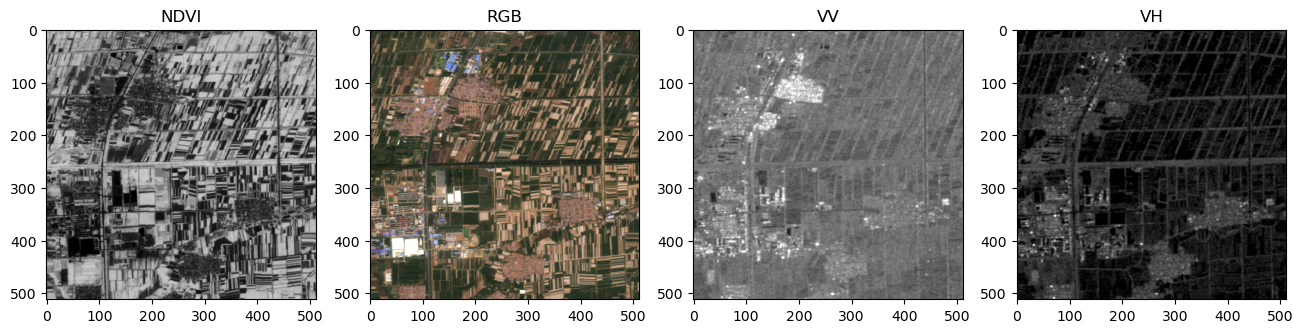

In [13]:
fig, ax = plt.subplots(1, 4, figsize=(16, 10))
ax[0].imshow(Image.fromarray(np.asarray(NDVI_image) * 255))
ax[0].set_title("NDVI")
ax[1].imshow(RGB_image)
ax[1].set_title("RGB")
ax[2].imshow(VV_image)
ax[2].set_title("VV")
ax[3].imshow(VH_image)
ax[3].set_title("VH")
plt.show()